#### Imagine basic usage with Qualcomm Cloud AI 100

##### Installation of the Imagine SDK

##### Import the required library packages

In [1]:
from pprint import pprint
from imagine import ChatMessage,ImagineClient, ModelType
import base64
from IPython.display import Image,Audio

##### Set the Imagine API key

There are two ways to set the Imagine API key:

- Set the environment variable IMAGINE_API_KEY to your personal Imagine API key
- Pass your API key directly to ImagineClient(api_key="YOUR_API_KEY")

##### Set the Imagine API key using an environment variable

##### Set the Imagine API key using ImagineClient

In [2]:
endpoint = "https://cloudai.cirrascale.com/apis/v2" # Imagine endpoint url
api_key = "YOUR_IMAGINE_API_KEY" # Imagine api key 

client = ImagineClient(api_key=api_key,endpoint=endpoint)

##### Print all available models

All available models are divided into the following model type groups:
- EMBEDDING
- LLM
- RERANKER
- TEXT_TO_IMAGE
- TRANSCRIBE
- TRANSLATE

Please refer https://imagine-sdk.qualcomm.com/api/imagine_clients.html#imagine.ImagineClient.get_available_models_by_type for more details.

In [3]:
# Check all available models along with their model types
all_models = client.get_available_models_by_type()
pprint(all_models)

{<ModelType.EMBEDDING>: ['BAAI/bge-large-en-v1.5'],
 <ModelType.LLM>: ['Llama-3.1-8B',
                   'Llama-3.3-70B',
                   'Phi-4',
                   'Qwen2.5-Coder-32B'],
 <ModelType.RERANKER>: ['BAAI/bge-reranker-base'],
 <ModelType.TEXT_TO_IMAGE>: ['stabilityai/sdxl-turbo'],
 <ModelType.TRANSCRIBE>: ['whisper-tiny'],
 <ModelType.TRANSLATE>: ['Helsinki-NLP/opus-mt-en-es',
                         'Helsinki-NLP/opus-mt-en-fr']}


##### Model Type : Embedding

The Imagine SDK supports creating embeddings from text input, which can be used in various applications.

Please refer https://imagine-sdk.qualcomm.com/api/imagine_clients.html#imagine.ImagineClient.embeddings for more details about API.

In [4]:
model_name = "BAAI/bge-large-en-v1.5" # Update the available choice of embedding models here that you want to use
input_text = ["How are you", "Have a great day ahead", "Good Morning"] # List of input texts to be used for embedding

embedding_response = client.embeddings(texts=input_text,model=model_name)

print(len(embedding_response.data)) # total number embedding data will be same as the number of input text

# print embedding one by one for each input text 
for i in range(0,len(input_text)):
    print("Embedding for : "+ input_text[i])
    print(embedding_response.data[i])
    print("\n")

3
Embedding for : How are you
object='embedding' embedding=[0.0689697265625, -0.023468017578125, -0.054351806640625, 0.04541015625, -0.01171875, -0.056732177734375, 0.01123046875, 0.05804443359375, 0.027923583984375, 0.0189666748046875, 0.0149383544921875, 0.00955963134765625, -0.00864410400390625, -0.0038604736328125, -0.07244873046875, -0.0164337158203125, -0.01082611083984375, -0.0333251953125, -0.01558685302734375, 0.003797531127929687, -0.043243408203125, 0.0294342041015625, -0.070556640625, 0.045806884765625, -0.0297088623046875, 0.0172271728515625, -0.0032672882080078125, 0.01464080810546875, 0.03765869140625, 0.0400390625, -0.036956787109375, 0.0167236328125, 0.01323699951171875, -0.0472412109375, 0.0048065185546875, -0.043060302734375, 0.0169830322265625, 0.00463104248046875, -0.0081329345703125, -0.02618408203125, 0.009063720703125, 0.0137939453125, 0.043304443359375, -0.01531219482421875, -0.074462890625, -0.0017118453979492188, 0.005641937255859375, -0.049346923828125, 0.01

##### Model Type : Chat

Below is an example for Chat, which takes an input prompt and generates output text based on the input text.

Please refer https://imagine-sdk.qualcomm.com/api/imagine_clients.html#imagine.ImagineClient.chat for more details.

In [5]:
model_name = "Llama-3.1-8B" # update available choice of "Model Type:LLM" which you want to use
prompt="What are healthy fruits" # provide input prompt

chat_response = client.chat(
    messages=[ChatMessage(role="user", content=prompt)],
    model=model_name,
    max_tokens=1024,
)
print(chat_response.first_content)

Here's a comprehensive list of healthy fruits that are rich in essential nutrients, vitamins, and minerals:

**Berries**

1. **Blueberries**: High in antioxidants, fiber, and vitamins C and K.
2. **Strawberries**: Rich in vitamin C, potassium, and fiber.
3. **Raspberries**: High in vitamin C, manganese, and fiber.
4. **Cranberries**: May help prevent urinary tract infections and support heart health.
5. **Goji berries**: Rich in vitamins A and C, potassium, and fiber.

**Citrus Fruits**

1. **Oranges**: High in vitamin C, vitamin A, and potassium.
2. **Grapefruits**: Rich in vitamin C, vitamin A, and potassium.
3. **Lemons**: High in vitamin C and flavonoids.
4. **Limes**: Rich in vitamin C and flavonoids.
5. **Tangerines**: High in vitamin C and potassium.

**Tropical Fruits**

1. **Mangoes**: Rich in vitamins A and C, potassium, and fiber.
2. **Pineapples**: High in vitamin C, manganese, and fiber.
3. **Papayas**: Rich in vitamin C, potassium, and an enzyme called papain.
4. **Kiwi**

##### Streaming in small chunks in case of longer response

This will be helpful to provide output to user as soon as it is available so that user do not need to wait until complete generation of output.

Please refer https://imagine-sdk.qualcomm.com/api/imagine_clients.html#imagine.ImagineClient.chat_stream for more details about API.

In [6]:
model_name = "Llama-3.1-8B" # update available choice of "Model Type:LLM" which you want to use
prompt="What are healthy fruits" # provide input prompt

for chunk in client.chat_stream(
    messages=[ChatMessage(role="user",content=prompt)],
    model=model_name,
    max_tokens=1024,
):
    if chunk.first_content is not None:
        print(chunk.first_content, end="", flush=True)

Here's a comprehensive list of healthy fruits that are rich in essential nutrients, vitamins, and minerals:

**Berries**

1. **Blueberries**: High in antioxidants, fiber, and vitamins C and K.
2. **Strawberries**: Rich in vitamin C, potassium, and fiber.
3. **Raspberries**: High in vitamin C, manganese, and fiber.
4. **Cranberries**: May help prevent urinary tract infections and support heart health.
5. **Goji berries**: Rich in vitamins A and C, potassium, and fiber.

**Citrus Fruits**

1. **Oranges**: High in vitamin C, vitamin A, and potassium.
2. **Grapefruits**: Rich in vitamin C, vitamin A, and potassium.
3. **Lemons**: High in vitamin C and flavonoids.
4. **Limes**: Rich in vitamin C and flavonoids.
5. **Tangerines**: High in vitamin C and potassium.

**Tropical Fruits**

1. **Mangoes**: Rich in vitamins A and C, potassium, and fiber.
2. **Pineapples**: High in vitamin C, manganese, and fiber.
3. **Papayas**: Rich in vitamin C, potassium, and an enzyme called papain.
4. **Kiwi**

##### Model Type : Reranker

Imagine provides an API for reranking, which can be useful to include as part of a RAG workflow.

Please refer https://imagine-sdk.qualcomm.com/api/imagine_clients.html#imagine.ImagineClient.reranker for more details.

In [7]:
# Query string for reranker input
query = "what is a panda?"
# Documents to be reranked - list of strings
documents = [
        "The giant panda (Ailuropoda melanoleuca), sometimes called a panda bear",
        "Paris is in France",
        "Kung fu panda is a movie",
        "Pandas are animals that live in cold climate",
    ]
# reranker model name
model="BAAI/bge-reranker-base"

# The number of most relevant documents to return. 
# If not specified, the reranked results of all documents will be returned.
num_rel_doc=2

# Set True to return documents in the response
return_documents=True

In [8]:
reranker_response = client.reranker(
    query=query,
    documents=documents,
    return_documents=return_documents,
    model=model,
    top_n=num_rel_doc,
)

pprint(reranker_response.data)

[ReRankerObject(document='Pandas are animals that live in cold climate', index=3, relevance_score=5.34765625),
 ReRankerObject(document='The giant panda (Ailuropoda melanoleuca), sometimes called a panda bear', index=0, relevance_score=2.533203125)]


##### Model Type : Text to Image

Imagine provides an API to generate images using a text prompt.

Please refer https://imagine-sdk.qualcomm.com/api/imagine_clients.html#imagine.ImagineClient.images_generate for more details.

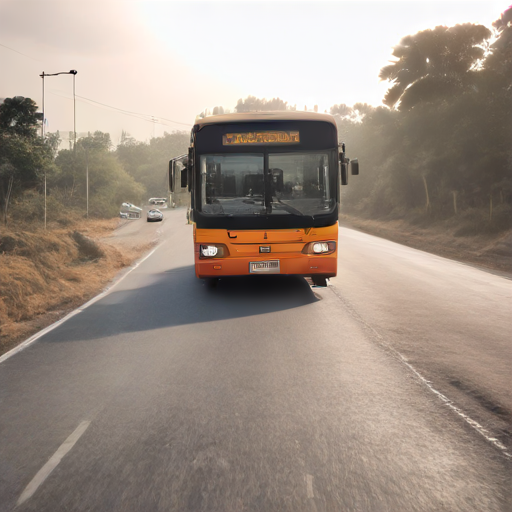

In [9]:
prompt = "Bus running on the road" # provide prompt here
num_images = 1 #number of images to be generated
negative_prompt = "disfigured, ugly, bad, immature" # characteristics to avoid for image generation.
model="stabilityai/sdxl-turbo" # model to be used for image generation

# Generate images using model
images_response = client.images_generate(
    prompt=prompt,
    model=model,
    n=num_images,
    negative_prompt=negative_prompt,
    response_format="b64_json",
)

# Display generated image
image_data=base64.decodebytes(images_response.data[0].b64_json.encode())
Image(image_data)

##### Model Type : Transcribe

Imagine SDK provides an API to convert audio to text data.

Please refer https://imagine-sdk.qualcomm.com/api/imagine_clients.html#imagine.ImagineClient.transcribe for more details.

In [10]:
input = "/local/mnt2/workspace/test.mp3" # path to audio file
model = "whisper-tiny" # model name

# play the input audio file
audio = Audio(input)
display(audio)

# Generate text response from audio file 
response = client.transcribe(input_file=input,model=model)
print(response.text)

 My dear Fanny, you feel these things a great deal too much. I am most happy that you like the chain.


##### Model Type: Translate

Imagine SDK supports translation between different languages based on available models. Please select the input and output languages according to the model used in the API.

Please refer https://imagine-sdk.qualcomm.com/api/imagine_clients.html#imagine.ImagineClient.translate for more details.


In [11]:
model = "Helsinki-NLP/opus-mt-en-fr" # model name

translate_response = client.translate(
    prompt="Good Morning, Have a Great day ahead",
    model=model,
)

print(translate_response.first_text)

Bonjour, bonne journée à l'avance
